In [14]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten


In [15]:
(X_train,y_train),(X_test,y_test) = keras.datasets.mnist.load_data()

In [16]:
X_train.shape # 60000 images of 28*28pixels

(60000, 28, 28)

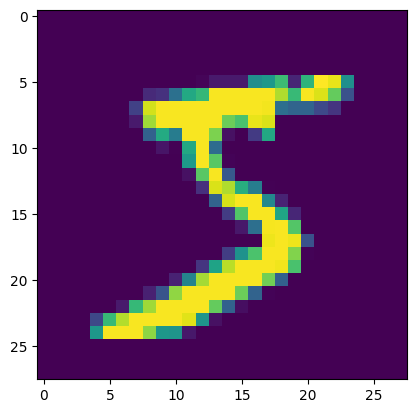

In [17]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0])

In [18]:
X_train=X_train/255
X_test=X_test/255

In [19]:
model=Sequential()

model.add(Flatten(input_shape=(28,28))) #2d array ko 1d array me taki 784 input dim ho ske
model.add(Dense(128,activation='relu')) # 1st hidden layer
model.add(Dense(32,activation='relu')) # 2st hidden layer # firsttime only 1 layer was their
model.add(Dense(10,activation='softmax')) # output layer,10 number he toh 10

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
model.summary()
# 784*128+128(bias)
# 128*10+10(bias)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])
# sparse_categorical_crossentropy me categorical_crossentropy me itna farak he bas spaese me one not encoding nahi krni padti

In [22]:
history=model.fit(X_train,y_train,epochs=25,validation_split=0.2) 
# 25 epochs ate second time first time it was 10
# vali_split sath me accuracy batayega 80 pecent ka bhi 20 percetn kam krke unpe test arega live

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9168 - loss: 0.2836 - val_accuracy: 0.9566 - val_loss: 0.1484
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9649 - loss: 0.1192 - val_accuracy: 0.9671 - val_loss: 0.1093
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9761 - loss: 0.0816 - val_accuracy: 0.9693 - val_loss: 0.1018
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9806 - loss: 0.0624 - val_accuracy: 0.9719 - val_loss: 0.0914
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9853 - loss: 0.0471 - val_accuracy: 0.9695 - val_loss: 0.1049
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9876 - loss: 0.0391 - val_accuracy: 0.9772 - val_loss: 0.0846
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9898 - loss: 0.0311 - val_accuracy: 0.9754 - val_loss: 0.0934
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9920 - loss: 0.0253 - 

In [23]:
y_prob=model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [24]:
y_pred=y_prob.argmax(axis=1)

In [25]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9798

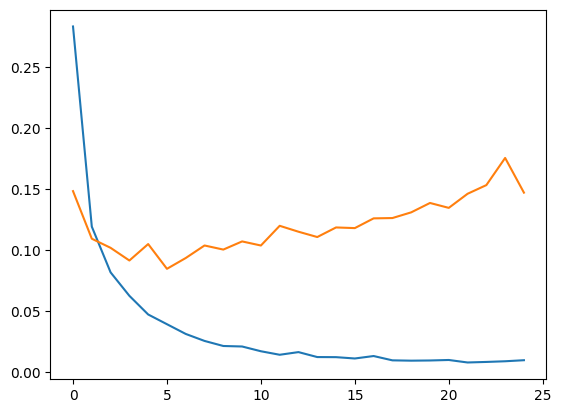

In [26]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

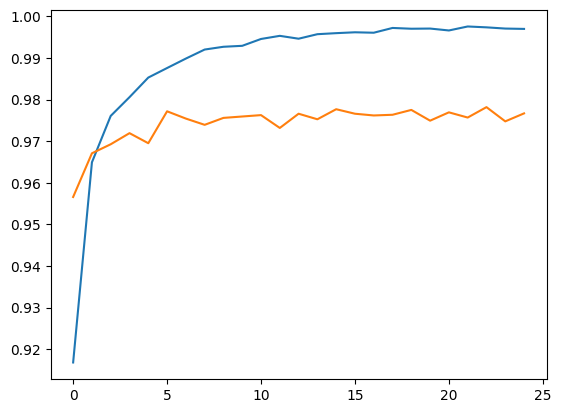

In [28]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

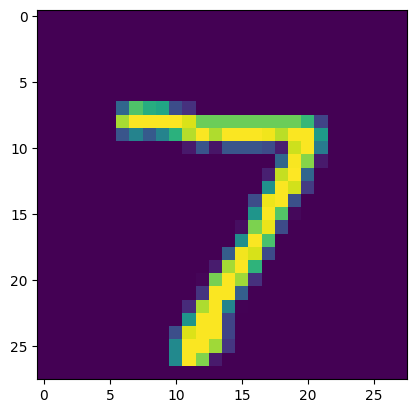

In [29]:
plt.imshow(X_test[0])

In [32]:
model.predict(X_test[0].reshape(1,28,28))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


array([[2.1112455e-19, 8.6898712e-13, 4.2100672e-12, 2.5372936e-13,
        1.2441989e-20, 1.8649667e-19, 2.2706954e-25, 1.0000000e+00,
        2.3711409e-18, 1.5242851e-12]], dtype=float32)

In [33]:
model.predict(X_test[0].reshape(1,28,28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


array([7])